### Vulnerability Data - Flood depth vs damage fraction

In [1]:
flood_depths = [
    0,
    0.5,
    1,
    1.5,
    2,
    3,
    4,
    5,
    6
]
damage_fractions = [
    0.00,
    0.25,
    0.40,
    0.50,
    0.60,
    0.75,
    0.85,
    0.95,
    1.00
]


In [2]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def get_damage_fraction(depth):
    """
    Get damage fraction for a given flood depth using polynomial interpolation.
    For depths outside the range, we clamp the values to [0, 1].
    
    Args:
        depth (float): Flood depth in meters
        
    Returns:
        float: Damage fraction between 0 and 1
    """
    # Create interpolation function
    f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
    return float(f(depth))

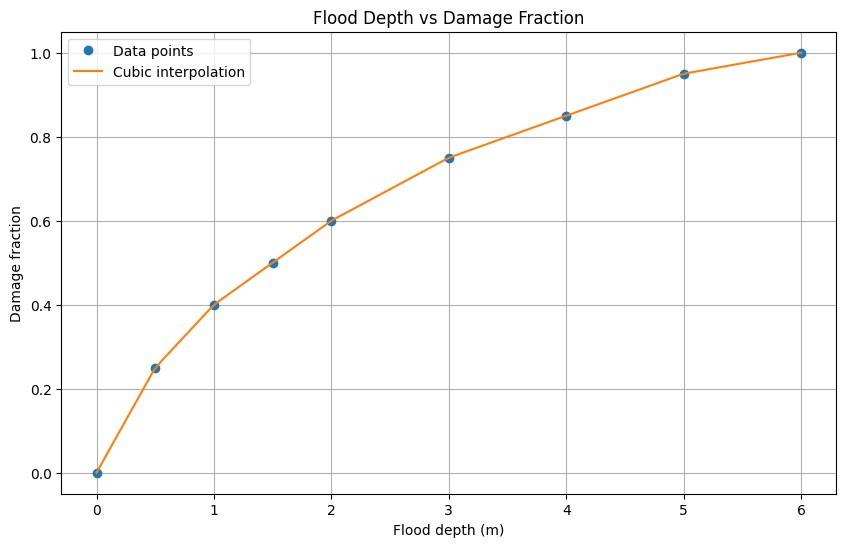

In [3]:
# Create points for smooth curve visualization
depths_smooth = np.linspace(0, 6, 100)
damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

# Plot the data and fitted curve
plt.figure(figsize=(10, 6))
plt.plot(flood_depths, damage_fractions, "o", label="Data points")
plt.plot(depths_smooth, damage_smooth, "-", label="Cubic interpolation")
plt.xlabel("Flood depth (m)")
plt.ylabel("Damage fraction")
plt.title("Flood Depth vs Damage Fraction")
plt.grid(True)
plt.legend()
plt.show()